In [13]:
import os
import pandas as pd
import numpy as np
import logging
from pathlib import Path
import matplotlib.pyplot as plt
import re
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm


In [14]:
# == Configuration ==
# === Logging format: timestamp - level - message ===
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURRENT_DIR = Path.cwd()
PATH_RESULTS = CURRENT_DIR / 'results'
PATH_Z = CURRENT_DIR.parent.parent / 'Data' / 'IntermediateData'/ 'latents_full'/ 'latents_full.npz'
PATH_Z = '/Users/hyijie/Desktop/My_projecting/biiigProject/tmp/low_rank_r5_no_cpp_prior_notebook_runs/20260704_211437/Data/IntermediateData/latents_low_rank_r5_no_cpp_prior/latents_low_rank_r5_no_cpp_prior.npz'

PATH_METADATA = CURRENT_DIR.parent.parent / 'Data' / 'ProcessedData'/ 'metadata.csv'   
PATH_TRACE = CURRENT_DIR.parent.parent /'Data'/ 'model_traces'/ 'm5_traces.csv'
PATH_RESULTS_JOINT = CURRENT_DIR.parent.parent /'Data'/ 'joint-modeling'/ 'data_joint_modeling_all.csv'

PATH_CPP = CURRENT_DIR.parent.parent / 'Data' / 'ProcessedData' /'eeg_cpp_trials.npy'


In [15]:
# load data
data_z = np.load(PATH_Z, allow_pickle=True)['latents']
data_eeg = np.load(PATH_CPP, allow_pickle=True)
data_erp = np.nanmean(data_eeg, axis=2)
data_metadata = pd.read_csv(PATH_METADATA)
assert len(data_z) == len(data_metadata) == len(data_erp), f" feature and behavior data are unaligned: fearture:{len(data_z)}; behavior data:{len(data_metadata)}; erp data:{len(data_erp)}"

# Calculate *v*

In [16]:
# === load trace data and calculate v for each subject and their condition ===
condition = 'cue_dimensionality'
V_INTERCEPT = 'v_intercept'
V_CONDITION = f'v_{condition}_slope'
GROUPBY_COLS = ['subj_idx', f'{condition}']
FEATURE_COLS = ['ams', 'pams', 'slps', 'ams_bin', 'pam_bin', 'slp_bin']

data_v = pd.read_csv(PATH_TRACE)
data_joint_modeling = pd.read_csv(PATH_RESULTS_JOINT)
# === Step 2: Extract subject-level posterior means for drift parameters ===
v_intercept = (
    data_v
    .filter(regex=r'^v_Intercept_subj\.sub-STSWD\d+$')
    .mean(axis=0)
)

v_condition = (
    data_v
    .filter(regex=fr'^v_{condition}_subj\.sub-STSWD\d+$')
    .mean(axis=0)
)

assert len(v_intercept) == len(v_condition), 'The number of intercept and coherence slope parameters does not match.'

# === Step 3: Build subject-level parameter table ===
subj_ids = [
    re.search(r'\.(sub-STSWD\d+)$', col).group(1)
    for col in v_intercept.index
]

v_params = pd.DataFrame({
    'subj_idx': subj_ids,
    V_INTERCEPT: v_intercept.to_numpy(),
    V_CONDITION: v_condition.to_numpy()
})

# === Step 4: Aggregate behavioral and EEG-derived features by subject and coherence ===
erp_v = (
    data_joint_modeling
    .groupby(GROUPBY_COLS)[FEATURE_COLS]
    .mean()
    .reset_index()
)

# === Step 5: Merge DDM parameters into the aggregated table ===
erp_v = erp_v.merge(v_params, on='subj_idx', how='left')
assert erp_v[V_INTERCEPT].notna().all(), 'Missing subject intercept values after merge.'
assert erp_v[V_CONDITION].notna().all(), 'Missing subject coherence slope values after merge.'

# === Step 6: Compute drift rate for each coherence level ===
erp_v['v'] = (erp_v[V_INTERCEPT] + erp_v[V_CONDITION] * erp_v[condition])
# ⚠️⚠️ remove subject 132 condtion 1 for this specific dataset
erp_v = pd.DataFrame(erp_v.drop(132))
v = erp_v['v']

In [17]:
v.shape

(163,)

# Calculate CPP

In [18]:
# add metadata for cpp data and calculate mean
column_subid_condition = data_metadata[['subj_idx', 'cue_dimensionality','probe_rt', 'probe_accuracy']]

data_erp_metadata = np.column_stack((column_subid_condition, data_erp))

data_erp_metadata = pd.DataFrame(data_erp_metadata)

erp = (
    data_erp_metadata
    .groupby([0, 1], as_index=False)
    .mean()
)

# == calculate CPP slopes ==
time_windows = (0.82, 0.92)
sample_rate = 256

start_col = int(time_windows[0] * sample_rate) + 4
end_col = int(time_windows[1] * sample_rate) + 4

# select time window
data4slope = erp.iloc[:, start_col:end_col]

# force convert to numeric float
data4slope = data4slope.apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)

n_trial = data4slope.shape[0]
time_vector = np.arange(data4slope.shape[1]) / sample_rate

# calculate slope
slope = np.array([
    np.polyfit(time_vector, data4slope[i, :], deg=1)[0]
    for i in range(n_trial)
])

# add slope as new column
erp['slope'] = slope

# == calculate CPP amplitude ==
time_windows = (0.82, 0.92)
sample_rate = 256

start_col = int(time_windows[0] * sample_rate) + 4
end_col = int(time_windows[1] * sample_rate) + 4

# select time window
data4ams = erp.iloc[:, start_col:end_col]

# force convert to numeric float
data4ams = data4ams.apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)

# calculate amplitude
n_trial = data4ams.shape[0]
ams = np.array([np.nanmean(data4ams[i, :]) for i in range(n_trial)]) 

# add amplitude as new column
erp['ams'] = ams

# == calculate CPP peak amplitude ==
time_windows = (0.95, 1.05)
sample_rate = 256

start_col = int(time_windows[0] * sample_rate) + 4
end_col = int(time_windows[1] * sample_rate) + 4

# select time window
data4pams = erp.iloc[:, start_col:end_col]

# force convert to numeric float
data4pams = data4pams.apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)

# calculate amplitude
n_trial = data4pams.shape[0]
pams = np.array([np.nanmax(data4pams[i, :]) for i in range(n_trial)]) 

# add peak amplitude as new column
erp['pams'] = pams

# == calculate rt ==
erp['rt'] = erp.iloc[:, 2]
erp['acc'] = erp.iloc[:, 3]

data_cpp = erp[[0, 1, 'rt', 'acc', 'slope', 'ams', 'pams']]

data_cpp = data_cpp.rename(columns={
    data_cpp.columns[0]: 'subj_id',
    data_cpp.columns[1]: 'condition'
})

/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_58693/992586812.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .mean()


In [19]:
data_cpp.shape

(163, 7)

# Merge Z and v into data_cpp

In [20]:
# ===============================
# Get subject and condition
# ===============================

subj_idx = data_metadata['subj_id'].values
condition = data_metadata['condition'].values
# or:
# condition = data_metadata['cue_dimensionality'].values

assert data_z.shape[0] == len(subj_idx) == len(condition)

# ===============================
# Create subject-condition groups
# ===============================

group_df = pd.DataFrame({
    'subj_id': subj_idx,
    'condition': condition
})

# group_idx tells which subject-condition group each trial belongs to
group_idx, unique_groups = pd.factorize(
    pd.MultiIndex.from_frame(group_df)
)

# convert unique groups back to dataframe
mean_metadata = unique_groups.to_frame(index=False)

n_groups = len(mean_metadata)

# ===============================
# Average data_z by subject and condition
# ===============================

mean_z = np.zeros((n_groups, data_z.shape[1], data_z.shape[2]))
counts = np.zeros(n_groups)

# sum data within each subject-condition group
np.add.at(mean_z, group_idx, data_z)

# count trials within each subject-condition group
np.add.at(counts, group_idx, 1)

# average
mean_z = mean_z / counts[:, None, None]
# ⚠️⚠️ remove subject 132 condtion 1 for this specific dataset
mean_z = np.delete(mean_z, 132, axis=0)


In [21]:
# ===get specific timewindows for Z values===
# early period
time_window_early = {'early': (0, 0.3)}
time_window_response = {'response': (0.7,1)}
time_windows_across_response = {'across_response': (0.8,1.1)}
time_window_late = {'late': (1,1.2)}
time_windows_slps = {'slps_ams': (0.82, 0.92)}
time_windows_pams = {'pams': (0.95, 1.05)}

data_merge = data_cpp.copy()
time_window = [time_window_early,
               time_window_response,
               time_windows_across_response,
               time_window_late,
               time_windows_slps,
               time_windows_pams]

for tw in time_window:
    for key, time in tw.items():
        start_idx = int(round(time[0] * sample_rate))
        end_idx = int(round(time[1] * sample_rate))
        # Extract z values in the target time window
        data_z_target = mean_z[:, start_idx:end_idx, :]
        # Average z within the target time window
        data_z_avg = np.nanmean(data_z_target, axis=1)
        for r in range(data_z_avg.shape[1]):
            data_merge[f'{key}_r{r}'] = data_z_avg[:, r]

data_merge['v'] = v

# Calculate the correlation between v and and behavior data

In [22]:
def z_score(x):
    return (x - x.mean()) / x.std()


data_merge['rt'] = pd.to_numeric(data_merge['rt'], errors='coerce')
data_merge['acc'] = pd.to_numeric(data_merge['acc'], errors='coerce')
data_merge['condition'] = pd.to_numeric(data_merge['condition'], errors='coerce')
data_merge['v'] = pd.to_numeric(data_merge['v'], errors='coerce')
# log RT
data_merge['log_rt'] = np.log(data_merge['rt'])

# convert 1D variables to 2D columns
acc = data_merge['acc'].to_numpy(dtype=np.float32).reshape(-1, 1)
condition = data_merge['condition'].to_numpy(dtype=np.float32).reshape(-1, 1)
rt = data_merge['log_rt'].to_numpy(dtype=np.float32).reshape(-1, 1)
slope = data_merge['slope'].to_numpy(dtype=np.float32).reshape(-1, 1)
slope_z = z_score(slope)
ams = data_merge['ams'].to_numpy(dtype=np.float32).reshape(-1, 1)
ams_z = z_score(ams)
pams = data_merge['pams'].to_numpy(dtype=np.float32).reshape(-1, 1)
pams_z = z_score(pams)

# dummy coding for subject
subj_dummies = pd.get_dummies(data_merge["subj_id"], drop_first=True).values.astype(np.float32)

In [23]:
# convert 1D variables to 2D columns
acc = data_merge['acc'].to_numpy(dtype=np.float32).reshape(-1, 1)
condition = data_merge['condition'].to_numpy(dtype=np.float32).reshape(-1, 1)
rt = data_merge['log_rt'].to_numpy(dtype=np.float32).reshape(-1, 1)

# dummy coding for subject
subj_dummies = pd.get_dummies(data_merge["subj_id"], drop_first=True).values.astype(np.float32)

# M0_baseline

In [24]:
#x = np.hstack([subj_dummies, acc, condition, rt]).astype(np.float32)
x_beh = np.hstack([acc, condition, rt]).astype(np.float32)

y = v

X_beh = sm.add_constant(x_beh)
model_beh = sm.OLS(y, X_beh, missing='drop').fit()
print(model_beh.summary())  


                            OLS Regression Results                            
Dep. Variable:                      v   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     81.61
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           5.19e-32
Time:                        21:26:57   Log-Likelihood:                -36.813
No. Observations:                 163   AIC:                             81.63
Df Residuals:                     159   BIC:                             94.00
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3087      0.178      1.733      0.0

In [25]:
x_slps = np.hstack([slope_z, acc, condition, rt]).astype(np.float32)
#x = np.hstack([acc, condition, rt]).astype(np.float32)
y = v

X_slps = sm.add_constant(x_slps)
model_slps = sm.OLS(y, X_slps, missing='drop').fit()
print(model_slps.summary())


                            OLS Regression Results                            
Dep. Variable:                      v   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     60.97
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           4.59e-31
Time:                        21:26:57   Log-Likelihood:                -36.699
No. Observations:                 163   AIC:                             83.40
Df Residuals:                     158   BIC:                             98.87
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2964      0.181      1.642      0.1

In [26]:
x_ams = np.hstack([ams_z, acc, condition, rt]).astype(np.float32)
#x = np.hstack([acc, condition, rt]).astype(np.float32)
y = v

X_ams = sm.add_constant(x_ams)
model_ams = sm.OLS(y, X_ams, missing='drop').fit()
print(model_ams.summary())


                            OLS Regression Results                            
Dep. Variable:                      v   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     64.30
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           3.54e-32
Time:                        21:26:57   Log-Likelihood:                -34.035
No. Observations:                 163   AIC:                             78.07
Df Residuals:                     158   BIC:                             93.54
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3939      0.179      2.195      0.0

In [27]:
x_pams = np.hstack([pams_z, acc, condition, rt]).astype(np.float32)
#x = np.hstack([acc, condition, rt]).astype(np.float32)
y = v

X_pams = sm.add_constant(x_pams)
model_pams = sm.OLS(y, X_pams, missing='drop').fit()
print(model_pams.summary()) 


                            OLS Regression Results                            
Dep. Variable:                      v   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     63.69
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           5.63e-32
Time:                        21:26:57   Log-Likelihood:                -34.517
No. Observations:                 163   AIC:                             79.03
Df Residuals:                     158   BIC:                             94.50
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3826      0.180      2.130      0.0

In [28]:
x_cpp = np.hstack([slope_z,ams_z,pams_z, acc, condition, rt]).astype(np.float32)
#x = np.hstack([acc, condition, rt]).astype(np.float32)
y = v

X_cpp = sm.add_constant(x_cpp)
model_cpp = sm.OLS(y, X_cpp, missing='drop').fit()
print(model_cpp.summary())  


                            OLS Regression Results                            
Dep. Variable:                      v   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     42.70
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           1.52e-30
Time:                        21:26:57   Log-Likelihood:                -33.595
No. Observations:                 163   AIC:                             81.19
Df Residuals:                     156   BIC:                             102.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3806      0.182      2.094      0.0

In [29]:
# rank data
r_name = ['early_r0','early_r1','early_r2','early_r3','early_r4',
          'response_r0','response_r1','response_r2','response_r3','response_r4',
          'across_response_r0','across_response_r1','across_response_r2','across_response_r3','across_response_r4',
          'late_r0','late_r1','late_r2','late_r3','late_r4',
          'slps_ams_r0','slps_ams_r1','slps_ams_r2','slps_ams_r3','slps_ams_r4',
          'pams_r0','pams_r1','pams_r2','pams_r3','pams_r4']

adjusted_r2 = {}
for rank in r_name:
    rank_name = data_merge[rank].to_numpy(dtype=np.float32).reshape(-1, 1)
    x = np.hstack([rank_name,ams_z, acc, condition, rt]).astype(np.float32)
    y = v

    X = sm.add_constant(x)
    model_r = sm.OLS(y, X, missing='drop').fit()
    adjusted_r2[rank] = model_r.rsquared_adj


# 

In [30]:
adjusted_r2['beh'] = model_beh.rsquared_adj
adjusted_r2['cpp'] = model_cpp.rsquared_adj
adjusted_r2['slps'] = model_slps.rsquared_adj
adjusted_r2['ams'] = model_ams.rsquared_adj
adjusted_r2['pams'] = model_pams.rsquared_adj

adjusted_r2_df = pd.DataFrame({
    "rank": adjusted_r2.keys(),
    "adjusted_r2": adjusted_r2.values()
})

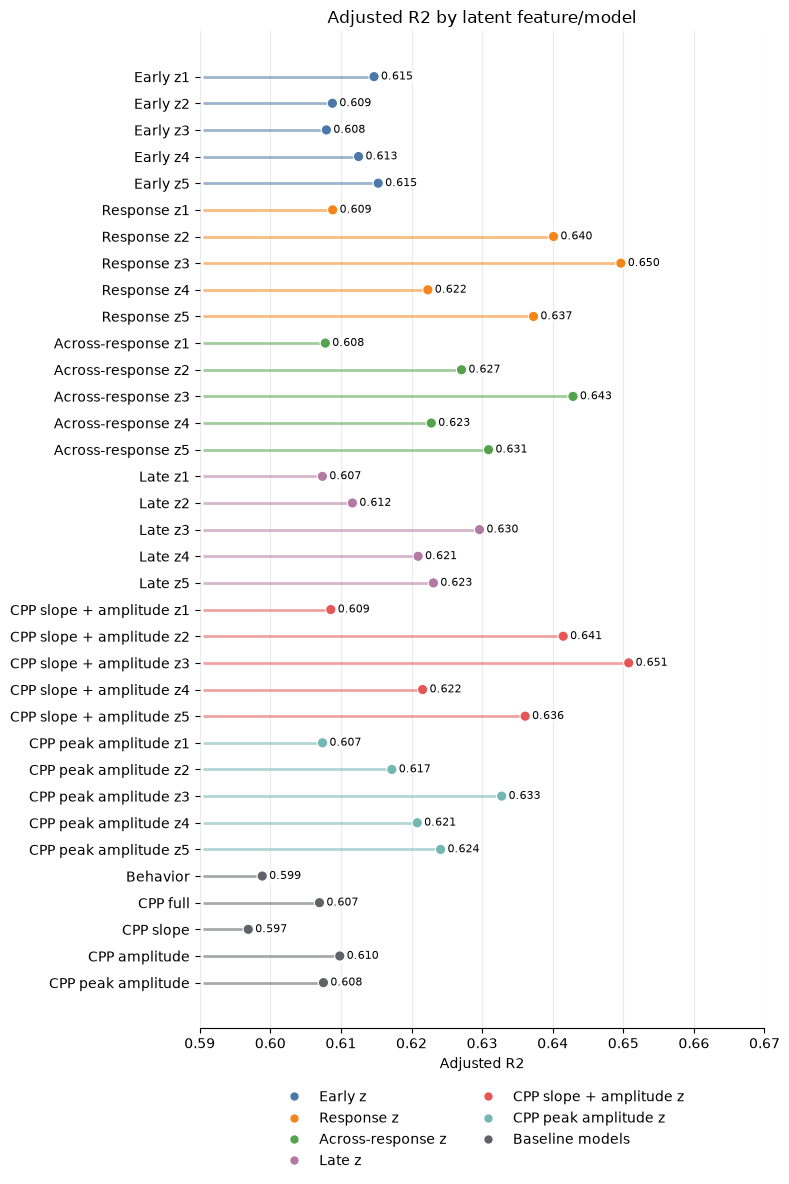

In [31]:
# Forest-style plot for adjusted R2 values
plot_df = adjusted_r2_df.copy()

baseline_labels = {
    'beh': 'Behavior',
    'cpp': 'CPP full',
    'slps': 'CPP slope',
    'ams': 'CPP amplitude',
    'pams': 'CPP peak amplitude',
}
group_labels = {
    'early': 'Early z',
    'response': 'Response z',
    'across_response': 'Across-response z',
    'late': 'Late z',
    'slps_ams': 'CPP slope + amplitude z',
    'pams': 'CPP peak amplitude z',
}
group_order = list(group_labels) + ['baseline']
baseline_order = ['beh', 'cpp', 'slps', 'ams', 'pams']

def parse_adjusted_r2_label(rank):
    if rank in baseline_labels:
        return pd.Series({
            'group': 'baseline',
            'component': np.nan,
            'label': baseline_labels[rank],
        })
    match = re.match(r'(.+)_r(\d+)$', str(rank))
    if match is None:
        return pd.Series({'group': 'other', 'component': np.nan, 'label': str(rank)})
    group, component = match.groups()
    label_prefix = group_labels.get(group, group)
    if label_prefix.endswith(' z'):
        label_prefix = label_prefix[:-2]
    return pd.Series({
        'group': group,
        'component': int(component) + 1,
        'label': f"{label_prefix} z{int(component) + 1}",
    })

plot_df = pd.concat([plot_df, plot_df['rank'].apply(parse_adjusted_r2_label)], axis=1)
plot_df['group_order'] = plot_df['group'].map({name: i for i, name in enumerate(group_order)}).fillna(len(group_order))
plot_df['component_order'] = plot_df['component'].fillna(
    plot_df['rank'].map({name: i + 1 for i, name in enumerate(baseline_order)})
)
plot_df = plot_df.sort_values(['group_order', 'component_order', 'rank']).reset_index(drop=True)

colors = {
    'early': '#4C78A8',
    'response': '#F58518',
    'across_response': '#54A24B',
    'late': '#B279A2',
    'slps_ams': '#E45756',
    'pams': '#72B7B2',
    'baseline': '#5F6368',
    'other': '#8A8A8A',
}

fig_height = max(6, 0.34 * len(plot_df))
fig, ax = plt.subplots(figsize=(8, fig_height))
y_pos = np.arange(len(plot_df))
point_colors = plot_df['group'].map(colors).fillna(colors['other'])
x_values = plot_df['adjusted_r2'].astype(float)
x_padding = max((x_values.max() - x_values.min()) * 0.12, 0.003)
x_min = max(0, x_values.min() - x_padding)
x_max = x_values.max() + x_padding * 2.6
x_tick_start = np.floor(x_min * 100) / 100
x_tick_stop = np.ceil(x_max * 100) / 100

ax.hlines(y=y_pos, xmin=x_min, xmax=plot_df['adjusted_r2'], color=point_colors, alpha=0.55, linewidth=2)
ax.scatter(plot_df['adjusted_r2'], y_pos, s=55, color=point_colors, edgecolor='white', linewidth=0.8, zorder=3)
ax.set_xlim(x_min, x_max)
ax.set_xticks(np.round(np.arange(x_tick_start, x_tick_stop + 0.001, 0.01), 2))

for y, value in zip(y_pos, plot_df['adjusted_r2']):
    ax.annotate(
        f'{value:.3f}',
        xy=(value, y),
        xytext=(5, 0),
        textcoords='offset points',
        va='center',
        ha='left',
        fontsize=8,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.2),
        clip_on=False,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['label'])
ax.invert_yaxis()
ax.set_xlabel('Adjusted R2')
ax.set_title('Adjusted R2 by latent feature/model')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right', 'left']].set_visible(False)

handles = [
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[group],
               markeredgecolor='white', markersize=7, label=label)
    for group, label in group_labels.items()
]
handles.append(
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=colors['baseline'],
               markeredgecolor='white', markersize=7, label='Baseline models')
)
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [32]:
#x = np.hstack([subj_dummies, acc, condition, rt]).astype(np.float32)
x_beh = np.hstack([acc, condition, rt]).astype(np.float32)
y = v
X_beh = sm.add_constant(x_beh)
model_beh = sm.OLS(y, X_beh, missing='drop').fit()



x_ams = np.hstack([ams, acc, condition, rt]).astype(np.float32)
y = v
X_ams = sm.add_constant(x_ams)
model_ams = sm.OLS(y, X_ams, missing='drop').fit()

# rank data
r_name_com = ['early_r0','early_r1','early_r2','early_r3','early_r4',
              'response_r0','response_r1','response_r2','response_r3','response_r4',
                'across_response_r0','across_response_r1','across_response_r2','across_response_r3','across_response_r4',
                'late_r0','late_r1','late_r2','late_r3','late_r4',
          'slps_ams_r0','slps_ams_r1','slps_ams_r2','slps_ams_r3','slps_ams_r4',
          'pams_r0','pams_r1','pams_r2','pams_r3','pams_r4']

sig_p_value = {}
for rank in r_name_com:
    rank_name = data_merge[rank].to_numpy(dtype=np.float32).reshape(-1, 1)
    x = np.hstack([rank_name,ams_z, acc, condition, rt]).astype(np.float32)
    y = v

    X = sm.add_constant(x)
    model_r = sm.OLS(y, X, missing='drop').fit()
    anova_table = anova_lm(model_ams, model_r)
    print(anova_table)

    sig_p_value[rank] = anova_table.iloc[1, -1]


   df_resid        ssr  df_diff   ss_diff         F    Pr(>F)
0     158.0  14.490398      0.0       NaN       NaN       NaN
1     157.0  14.219601      1.0  0.270797  2.989898  0.085751
   df_resid        ssr  df_diff   ss_diff         F    Pr(>F)
0     158.0  14.490398      0.0       NaN       NaN       NaN
1     157.0  14.437186      1.0  0.053212  0.578662  0.447978
   df_resid        ssr  df_diff   ss_diff         F   Pr(>F)
0     158.0  14.490398      0.0       NaN       NaN      NaN
1     157.0  14.468595      1.0  0.021803  0.236588  0.62736
   df_resid        ssr  df_diff   ss_diff        F   Pr(>F)
0     158.0  14.490398      0.0       NaN      NaN      NaN
1     157.0  14.300423      1.0  0.189974  2.08567  0.15068
   df_resid        ssr  df_diff   ss_diff         F   Pr(>F)
0     158.0  14.490398      0.0       NaN       NaN      NaN
1     157.0  14.197686      1.0  0.292711  3.236844  0.07392
   df_resid        ssr  df_diff   ss_diff        F    Pr(>F)
0     158.0  14.49039